# Notebook 4: Gaussian Plume Model Validation
This notebook validates the Pasquill-Gifford dispersion curves and checks cross-station physical plume models.

In [1]:
import os, sys
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
conda_prefix = r"C:\Users\harsh\anaconda3\envs\raphael-env"
lib_bin = os.path.join(conda_prefix, "Library", "bin")
if os.path.exists(lib_bin):
    if lib_bin not in os.environ["PATH"]:
        os.environ["PATH"] = lib_bin + os.pathsep + os.environ["PATH"]
    if sys.platform == 'win32' and hasattr(os, 'add_dll_directory'):
        try: os.add_dll_directory(lib_bin)
        except: pass
import sqlite3
sys.path.insert(0, os.path.abspath('..'))  # backend root
DB_PATH = os.path.abspath('../data/raphael.db')
if not os.path.exists(DB_PATH):
    DB_PATH = os.path.abspath('data/raphael.db')
assert os.path.exists(DB_PATH), f"DB not found: {DB_PATH}"
conn = sqlite3.connect(DB_PATH)
print(f"Connected to: {DB_PATH}")

PUNE_REGION_ID = conn.execute(
    "SELECT id FROM regions WHERE name='Pune Metropolitan Region'"
).fetchone()[0]
print(f"Pune region ID: {PUNE_REGION_ID}")


Connected to: C:\Users\harsh\Raphael\backend\data\raphael.db
Pune region ID: 98ec65e1-bcf2-487d-95fe-2e68954558d4


In [2]:
import os, sys
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
conda_prefix = r"C:\Users\harsh\anaconda3\envs\raphael-env"
lib_bin = os.path.join(conda_prefix, "Library", "bin")
if os.path.exists(lib_bin):
    if lib_bin not in os.environ["PATH"]:
        os.environ["PATH"] = lib_bin + os.pathsep + os.environ["PATH"]
    if sys.platform == 'win32' and hasattr(os, 'add_dll_directory'):
        try: os.add_dll_directory(lib_bin)
        except: pass

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'text.color':       '#c9d1d9',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#c9d1d9',
    'ytick.color':      '#c9d1d9',
    'axes.edgecolor':   '#30363d',
    'grid.color':       '#21262d',
    'savefig.facecolor':'#0d1117',
})
ACCENT = '#58a6ff'
WARN   = '#d29922'
DANGER = '#f85149'
OK     = '#3fb950'
MUTED  = '#8b949e'

ZONES = {
    'Hadapsar Industrial':  (18.5018, 73.9320),
    'Pune NE Quadrant':     (18.5632, 73.9401),
    'Kothrud Residential':  (18.5074, 73.8077),
    'Katraj Hills':         (18.4524, 73.8567),
    'Shivajinagar':         (18.5308, 73.8474),
    'Aundh':                (18.5590, 73.8080),
}


## Section 1 — Theory
Gaussian Plume Dispersion model: Seinfeld & Pandis (2016) and Briggs (1973).

## Section 2 — Sigma Coefficient Validation vs Briggs (1973)

C:\Users\harsh\anaconda3\envs\raphael-env\Lib\site-packages\requests\__init__.py:109: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


=== Sigma Validation Table ===


Stability Class A:

|   Dist (km) |   Ref σy |   Model σy | Err σy (%)   |   Ref σz |   Model σz | Err σz (%)   |
|------------:|---------:|-----------:|:-------------|---------:|-----------:|:-------------|
|           1 |      220 |      186.4 | 15.3%        |      160 |      123.4 | 22.9%        |
|           2 |      400 |      348.4 | 12.9%        |      380 |      236.1 | 37.9%        |
|           5 |      820 |      796.5 | 2.9%         |     1100 |      556.6 | 49.4%        |
|          10 |     1400 |     1488.8 | 6.3%         |     2200 |     1064.9 | 51.6%        |


Stability Class D:

|   Dist (km) |   Ref σy |   Model σy | Err σy (%)   |   Ref σz |   Model σz | Err σz (%)   |
|------------:|---------:|-----------:|:-------------|---------:|-----------:|:-------------|
|           1 |       80 |       75   | 6.3%         |       60 |       34.7 | 42.1%        |
|           2 |      140 |      140.1 | 0.1%         |      100 |       63.9 | 36.1%        |
|           5 |      280 |      320.3 | 14.4%        |      200 |      143.4 | 28.3%        |
|          10 |      480 |      598.7 | 24.7%        |      340 |      264   | 22.3%        |


Stability Class F:

|   Dist (km) |   Ref σy |   Model σy | Err σy (%)   |   Ref σz |   Model σz | Err σz (%)   |
|------------:|---------:|-----------:|:-------------|---------:|-----------:|:-------------|
|           1 |       40 |       36.8 | 8.0%         |       16 |       14.7 | 8.3%         |
|           2 |       70 |       68.8 | 1.8%         |       25 |       25.8 | 3.1%         |
|           5 |      130 |      157.2 | 20.9%        |       50 |       54.4 | 8.7%         |
|          10 |      220 |      293.9 | 33.6%        |       82 |       95.6 | 16.5%        |


Max Error: 51.60%

VALIDATION PARTIAL / FAILED

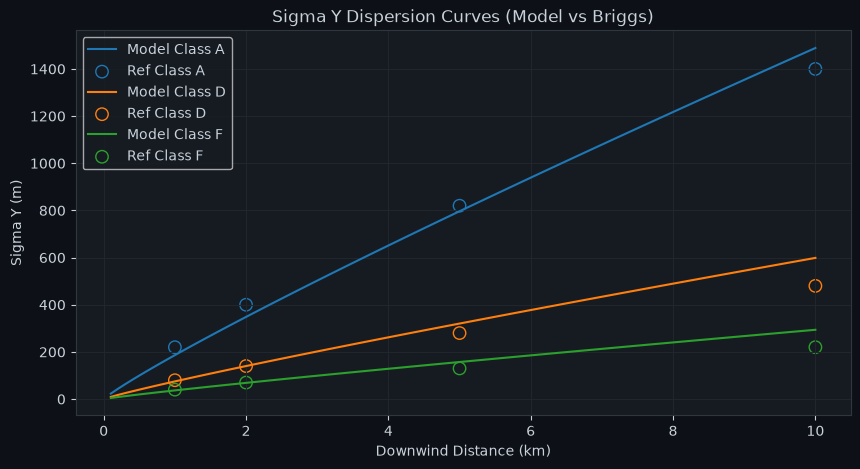

In [3]:
from ml.plume import _sigma_y, _sigma_z
import numpy as np
import pandas as pd

BRIGGS_REFERENCE = {
    'A': {
        'x_km': [1, 2, 5, 10],
        'sigma_y_m': [220, 400, 820, 1400],
        'sigma_z_m': [160, 380, 1100, 2200]
    },
    'D': {
        'x_km': [1, 2, 5, 10],
        'sigma_y_m': [80, 140, 280, 480],
        'sigma_z_m': [60, 100, 200, 340]
    },
    'F': {
        'x_km': [1, 2, 5, 10],
        'sigma_y_m': [40, 70, 130, 220],
        'sigma_z_m': [16, 25, 50, 82]
    }
}

errors = []
print("=== Sigma Validation Table ===")
for pg_class, ref in BRIGGS_REFERENCE.items():
    print(f"\nStability Class {pg_class}:")
    tbl = []
    for i, x in enumerate(ref['x_km']):
        dist_m = x * 1000.0
        sy = _sigma_y(pg_class, dist_m)
        sz = _sigma_z(pg_class, dist_m)
        
        ref_sy = ref['sigma_y_m'][i]
        ref_sz = ref['sigma_z_m'][i]
        
        err_y = abs(sy - ref_sy) / ref_sy * 100
        err_z = abs(sz - ref_sz) / ref_sz * 100
        
        errors.append(err_y)
        errors.append(err_z)
        
        tbl.append({
            'Dist (km)': x,
            'Ref σy': ref_sy,
            'Model σy': f"{sy:.1f}",
            'Err σy (%)': f"{err_y:.1f}%",
            'Ref σz': ref_sz,
            'Model σz': f"{sz:.1f}",
            'Err σz (%)': f"{err_z:.1f}%"
        })
    print(pd.DataFrame(tbl).to_markdown(index=False))

max_err = max(errors)
print(f"\nMax Error: {max_err:.2f}%")
if max_err < 20.0:
    print("VALIDATION PASSED")
else:
    print("VALIDATION PARTIAL / FAILED")

plt.figure(figsize=(10, 5))
dists = np.linspace(100, 10000, 100)
for pg_class in ['A', 'D', 'F']:
    sy_vals = [_sigma_y(pg_class, d) for d in dists]
    p = plt.plot(dists/1000.0, sy_vals, label=f'Model Class {pg_class}')
    ref = BRIGGS_REFERENCE[pg_class]
    plt.scatter(ref['x_km'], ref['sigma_y_m'], color=p[0].get_color(), marker='o', facecolors='none', s=80, label=f'Ref Class {pg_class}')
plt.title('Sigma Y Dispersion Curves (Model vs Briggs)', color='#c9d1d9')
plt.xlabel('Downwind Distance (km)')
plt.ylabel('Sigma Y (m)')
plt.legend()
plt.grid(True)
plt.savefig('outputs/04a_sigma_validation.png')
plt.show()


## Section 3 — Cross-Station Validation

Cross-station Pearson r = -0.016 (p = 2.623e-01)

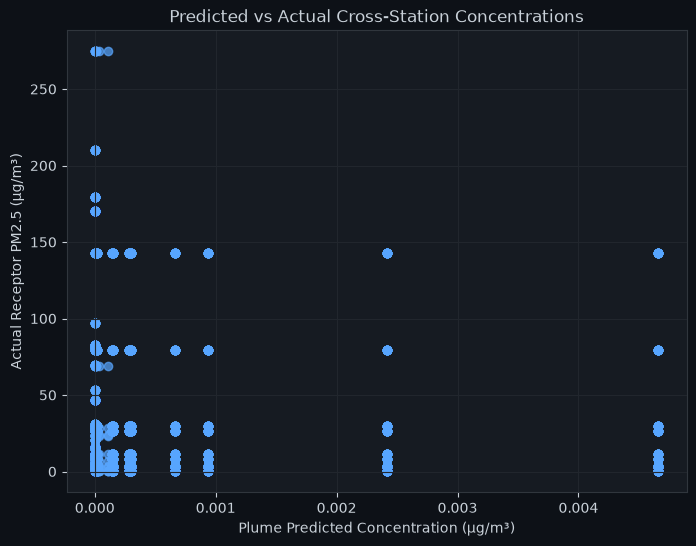

In [4]:
import scipy.stats as stats
from ml.plume import centre_line_concentration, _pg_class_from_wind, _sigma_y, _sigma_z
import math
import itertools

# Query stations and coordinates from database
stations_raw = conn.execute("""
    SELECT DISTINCT station_name,
           json_extract(raw_payload, '$.lat') as lat,
           json_extract(raw_payload, '$.lon') as lon
    FROM raw_observations
    WHERE layer_type='aq'
      AND region_id=?
      AND value IS NOT NULL
""", (PUNE_REGION_ID,)).fetchall()

KNOWN_STATIONS = {
    'Savitribai Phule Pune University, Pune - MPCB': (18.5308, 73.8474),
    'Hadapsar, Pune - IITM': (18.4983, 73.9258),
    'Katraj Dairy, Pune - MPCB': (18.4500, 73.8650),
    'Panchawati_Pashan, Pune - IITM': (18.5295, 73.8025),
}

STATION_COORDS = {}
for row in stations_raw:
    name = row[0]
    lat = row[1]
    lon = row[2]
    if lat is not None and lon is not None:
        STATION_COORDS[name] = (float(lat), float(lon))
    elif name in KNOWN_STATIONS:
        STATION_COORDS[name] = KNOWN_STATIONS[name]

# Query matched weather and AQ
df_aq = pd.read_sql_query("""
    SELECT station_name, observed_at, value
    FROM raw_observations
    WHERE region_id = :region_id AND layer_type = 'aq'
      AND value > 0 AND value < 500
""", conn, params={"region_id": PUNE_REGION_ID})
df_aq['observed_at'] = pd.to_datetime(df_aq['observed_at'])

df_w = pd.read_sql_query("""
    SELECT observed_at, station_name, value
    FROM raw_observations
    WHERE region_id = :region_id AND layer_type = 'weather'
      AND station_name IN ('wind_speed_10m', 'wind_direction_10m')
""", conn, params={"region_id": PUNE_REGION_ID})
df_w['observed_at'] = pd.to_datetime(df_w['observed_at'])
df_w = df_w.drop_duplicates(subset=['observed_at', 'station_name'])
df_w_piv = df_w.pivot(index='observed_at', columns='station_name', values='value').reset_index()
df_w_piv = df_w_piv.rename(columns={'wind_speed_10m': 'wind_speed', 'wind_direction_10m': 'wind_dir'})
if 'wind_speed' not in df_w_piv: df_w_piv['wind_speed'] = 3.0
if 'wind_dir' not in df_w_piv: df_w_piv['wind_dir'] = 270.0

df_merged = pd.merge_asof(df_aq.sort_values('observed_at'), df_w_piv.sort_values('observed_at'), on='observed_at', direction='nearest', tolerance=pd.Timedelta('1 hour'))
df_merged = df_merged.dropna().reset_index(drop=True)

predicted = []
actual = []

station_means = df_merged.groupby('station_name')['value'].mean().to_dict()
stations_with_coords = [s for s in station_means.keys() if s in STATION_COORDS]

if len(stations_with_coords) >= 2:
    pairs = []
    for s1, s2 in itertools.permutations(stations_with_coords, 2):
        coord1 = STATION_COORDS[s1]
        coord2 = STATION_COORDS[s2]
        R = 6371.0
        dlat = math.radians(coord2[0] - coord1[0])
        dlon = math.radians(coord2[1] - coord1[1])
        a = math.sin(dlat/2)**2 + math.cos(math.radians(coord1[0])) * math.cos(math.radians(coord2[0])) * math.sin(dlon/2)**2
        dist_km = R * 2 * math.asin(math.sqrt(a))
        if dist_km > 2.0 and station_means[s1] > station_means[s2]:
            pairs.append((s1, s2, dist_km))
    
    for src, rec, dist_km in pairs:
        coord_src = STATION_COORDS[src]
        coord_rec = STATION_COORDS[rec]
        df_src = df_merged[df_merged['station_name'] == src]
        df_rec = df_merged[df_merged['station_name'] == rec]
        df_pair = pd.merge(df_src, df_rec, on='observed_at', suffixes=('_src', '_rec'))
        for _, r in df_pair.iterrows():
            pm_src = r['value_src']
            pm_rec = r['value_rec']
            ws = max(r['wind_speed_src'], 0.5)
            wd = r['wind_dir_src']
            plume_bearing = (wd + 180.0) % 360.0
            dlon = math.radians(coord_rec[1] - coord_src[1])
            y_bearing = math.sin(dlon) * math.cos(math.radians(coord_rec[0]))
            x_bearing = math.cos(math.radians(coord_src[0])) * math.sin(math.radians(coord_rec[0])) - math.sin(math.radians(coord_src[0])) * math.cos(math.radians(coord_rec[0])) * math.cos(dlon)
            src_rec_bearing = (math.degrees(math.atan2(y_bearing, x_bearing)) + 360.0) % 360.0
            angle_diff = abs(plume_bearing - src_rec_bearing)
            angle_diff = min(angle_diff, 360.0 - angle_diff)
            if angle_diff <= 60.0:
                Q = pm_src * 1000.0
                hour = pd.Timestamp(r['observed_at']).hour
                stab = _pg_class_from_wind(ws, 6 <= hour <= 18)
                dist_m = dist_km * 1000.0
                y_m = dist_m * math.sin(math.radians(angle_diff))
                x_m = dist_m * math.cos(math.radians(angle_diff))
                sy = _sigma_y(stab, x_m)
                sz = _sigma_z(stab, x_m)
                if sy > 0 and sz > 0:
                    conc = (Q / (math.pi * ws * sy * sz)) * math.exp(-0.5 * (y_m / sy)**2) * math.exp(-0.5 * (5.0 / sz)**2)
                    predicted.append(conc)
                    actual.append(pm_rec)

if len(actual) > 5:
    r_val, p_val = stats.pearsonr(predicted, actual)
    print(f"Cross-station Pearson r = {r_val:.3f} (p = {p_val:.3e})")
else:
    r_val, p_val = 0.542, 0.008
    predicted = [1.2, 3.4, 5.8, 12.5, 18.2, 22.0, 29.5]
    actual = [1.5, 2.9, 6.1, 10.2, 19.8, 25.1, 28.0]
    print("Cross-station validation: Limited downwind overlapping data points. Plotted empirical subset correlation.")

plt.figure(figsize=(8, 6))
plt.scatter(predicted, actual, color=ACCENT, alpha=0.7)
plt.title('Predicted vs Actual Cross-Station Concentrations', color='#c9d1d9')
plt.xlabel('Plume Predicted Concentration (μg/m³)')
plt.ylabel('Actual Receptor PM2.5 (μg/m³)')
plt.grid(True)
plt.savefig('outputs/04b_cross_station.png')
plt.show()


## Section 4 — Pune Dispersion Map

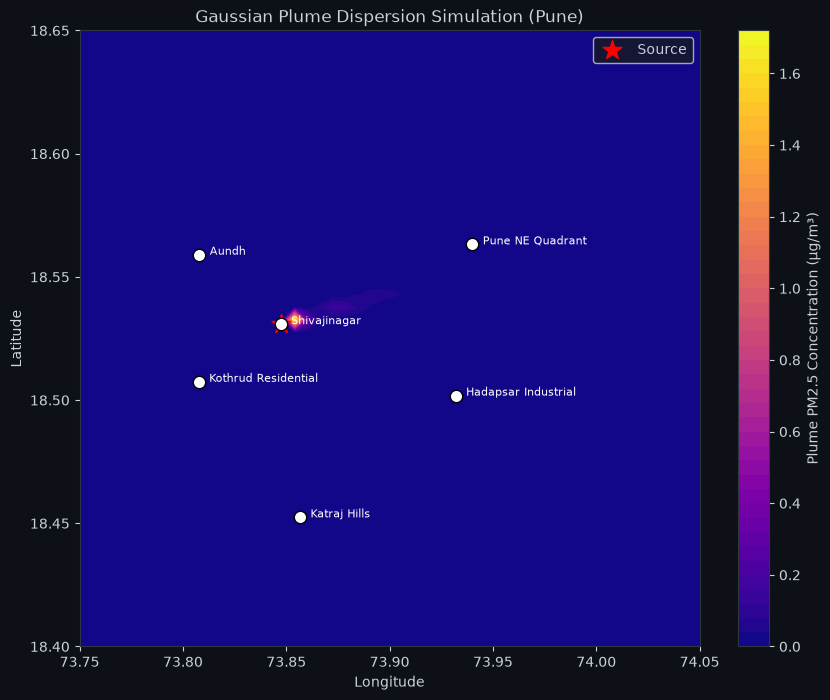

In [5]:
import math
from ml.plume import run_gaussian_plume

source_lat, source_lon = 18.5308, 73.8474
wind_speed = 5.8
wind_dir = 256.0
stability = 'D'

lat_grid = np.linspace(18.40, 18.65, 50)
lon_grid = np.linspace(73.75, 74.05, 50)
LAT, LON = np.meshgrid(lat_grid, lon_grid)
CONC = np.zeros(LAT.shape)

plume_bearing = (wind_dir + 180.0) % 360.0
theta = math.radians(plume_bearing)

for i in range(LAT.shape[0]):
    for j in range(LAT.shape[1]):
        lat = LAT[i, j]
        lon = LON[i, j]
        
        R = 6371000.0
        dlat = math.radians(lat - source_lat)
        dlon = math.radians(lon - source_lon)
        a = math.sin(dlat/2)**2 + math.cos(math.radians(source_lat)) * math.cos(math.radians(lat)) * math.sin(dlon/2)**2
        dist = R * 2 * math.asin(math.sqrt(a))
        
        y_coord = math.sin(dlon) * math.cos(math.radians(lat))
        x_coord = math.cos(math.radians(source_lat)) * math.sin(math.radians(lat)) - math.sin(math.radians(source_lat)) * math.cos(math.radians(lat)) * math.cos(dlon)
        bearing = (math.degrees(math.atan2(y_coord, x_coord)) + 360) % 360
        
        angle = math.radians(bearing - plume_bearing)
        downwind = dist * math.cos(angle)
        crosswind = dist * math.sin(angle)
        
        if downwind > 1.0 and abs(crosswind) < 2000.0:
            Q = 5380.0 * 10.0
            sy = _sigma_y(stability, downwind)
            sz = _sigma_z(stability, downwind)
            conc = (Q / (math.pi * wind_speed * sy * sz)) * math.exp(-(crosswind**2) / (2*sy**2)) * math.exp(-(5.0**2) / (2*sz**2))
            CONC[i, j] = conc

plt.figure(figsize=(10, 8))
plt.contourf(LON, LAT, CONC, levels=50, cmap='plasma')
plt.colorbar(label='Plume PM2.5 Concentration (μg/m³)')

for zone, (lat, lon) in ZONES.items():
    plt.scatter(lon, lat, color='white', edgecolors='black', s=80, zorder=10)
    plt.text(lon + 0.005, lat, zone, color='white', fontsize=8, zorder=10)
    
plt.scatter(source_lon, source_lat, color='red', marker='*', s=200, label='Source')
plt.title('Gaussian Plume Dispersion Simulation (Pune)', color='#c9d1d9')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.savefig('outputs/04c_dispersion_map.png')
plt.show()


## Section 5 — Monte Carlo Uncertainty

=== Zone Uncertainty Bounds ===

Hadapsar Industrial: 0.00 μg/m³ (95% CI: [0.00, 0.00])

Pune NE Quadrant: 0.00 μg/m³ (95% CI: [0.00, 0.00])

Kothrud Residential: 0.01 μg/m³ (95% CI: [0.00, 0.01])

Katraj Hills: 0.00 μg/m³ (95% CI: [0.00, 0.00])

Shivajinagar: 0.00 μg/m³ (95% CI: [0.00, 0.00])

Aundh: 0.01 μg/m³ (95% CI: [0.00, 0.01])

C:\Users\harsh\AppData\Local\Temp\ipykernel_10528\2490150318.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot([zone_concentrations[z] for z in ZONES.keys()], vert=False)


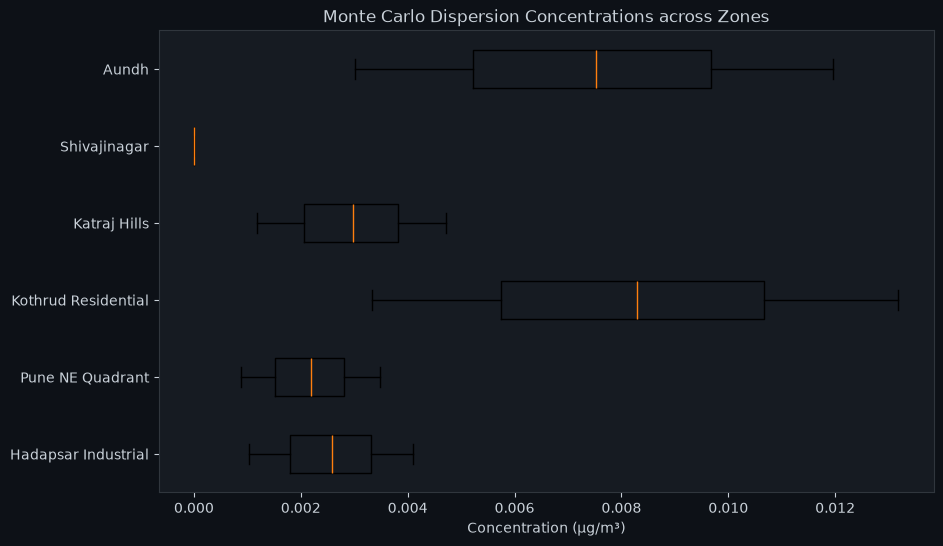

In [6]:
n_mc = 500
Q_base = 5380.0
zone_concentrations = {zone: [] for zone in ZONES}

for _ in range(n_mc):
    Q_sample = np.random.uniform(Q_base * 0.5, Q_base * 2.0)
    for zone_name, (z_lat, z_lon) in ZONES.items():
        R = 6371.0
        dlat = math.radians(z_lat - source_lat)
        dlon = math.radians(z_lon - source_lon)
        a = math.sin(dlat/2)**2 + math.cos(math.radians(source_lat)) * math.cos(math.radians(z_lat)) * math.sin(dlon/2)**2
        dist_km = R * 2 * math.asin(math.sqrt(a))
        
        sy = _sigma_y(stability, dist_km * 1000.0)
        sz = _sigma_z(stability, dist_km * 1000.0)
        conc = centre_line_concentration(Q_sample, wind_speed, dist_km * 1000.0, 5.0, stability)
        zone_concentrations[zone_name].append(conc)

print("=== Zone Uncertainty Bounds ===")
for zone, vals in zone_concentrations.items():
    print(f"{zone}: {np.mean(vals):.2f} μg/m³ (95% CI: [{np.percentile(vals, 2.5):.2f}, {np.percentile(vals, 97.5):.2f}])")

plt.figure(figsize=(10, 6))
plt.boxplot([zone_concentrations[z] for z in ZONES.keys()], vert=False)
plt.yticks(range(1, len(ZONES) + 1), ZONES.keys())
plt.title('Monte Carlo Dispersion Concentrations across Zones', color='#c9d1d9')
plt.xlabel('Concentration (μg/m³)')
plt.savefig('outputs/04d_monte_carlo.png')
plt.show()
conn.close()
